In [1]:
import numpy as np
import sys
import os
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from utils.Utils import (
    compute_functions, 
    compute_state_vector, 
    Kepler, OrbitTrasformations, 
    compute_jacobian_XoE,
    CanonicalUnits, 
    GravitationalParameters, 
    trasformation_E_to_X, 
    trasformation_X_to_E,
    P_E, 
    P_X_vectorized,
    )
import spiceypy as spy
import scipy.optimize as optimize
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
%load_ext autoreload 
%autoreload 2

In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

In [3]:
N = int(1e8)

a_uniform = np.random.uniform(0, 2, N)
e_uniform = np.random.uniform(0, 1, N)

#maping i as sin(i)
u = np.random.uniform(0,1,N)

mask = u <= 0.5
I1 = np.arcsin(2*u[mask])
I2 = np.pi - np.arcsin(2*(1-u[~mask]))
I = np.concatenate([I1, I2]) 

Omega_uniform = np.random.uniform(0, 2*np.pi, N)
w_uniform = np.random.uniform(0, 2*np.pi, N)
M_uniform = np.random.uniform(0, 2*np.pi, N)
q_uniform = a_uniform*(1-e_uniform)

elements = np.column_stack((a_uniform, e_uniform, I, Omega_uniform, w_uniform, M_uniform, q_uniform))

state_vectors = np.zeros((N, 6))
for el in tqdm(range(N)):
    a = a_uniform[el]
    e = e_uniform[el]
    i = I[el]
    Omega = Omega_uniform[el]
    w = w_uniform[el]
    M = M_uniform[el]

    x, y, z, vx, vy, vz = trasformation_E_to_X(a, e, i, Omega, w, M, mu)
    state_vectors[el] = np.array([x, y, z, vx, vy, vz])

100%|██████████| 100000000/100000000 [24:22<00:00, 68388.10it/s]


In [4]:
def P_E(i: float) -> float:
    a_max = 2; a_min = 0
    e_max = 1; e_min = 0
    
    pi = 1/2 * np.abs(np.cos(i))

    Omega_max = 2*np.pi; Omega_min = 0
    w_max = 2*np.pi; w_min = 0
    M_max = 2*np.pi; M_min = 0

    return 1/(a_max - a_min) * 1/(e_max - e_min) * pi * 1/(Omega_max - Omega_min) * 1/(w_max - w_min) * 1/(M_max - M_min)

def P_X(x: float, y: float, z: float, vx: float, vy: float, vz: float) -> float:
    a, e, i, Omega, w, M = trasformation_X_to_E(x, y, z, vx, vy, vz, mu)
    J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
    det = np.linalg.det(J)
    #print(det)
    inv_det = 1.0/det
    P = P_E() * abs(inv_det)
    return P

def P_X_vectorized(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, mu: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
        det = np.linalg.det(J) 
        inv_det = 1.0/det
        P.flat[idx] = P_E(i) * abs(inv_det)

    return P.reshape(shape)

In [27]:
xmin, xmax = (0.9039710143502464, 1.0960289856497536)
ymin, ymax = ( -0.09602898564975362, 0.09602898564975362)
zmin, zmax = (-0.09602898564975362, 0.09602898564975362)
vxmin, vxmax = (-0.5064245183055923, 0.5064245183055923)
vymin, vymax = (5.777598212496408, 6.790447249107593)
vzmin, vzmax = (-0.5064245183055923, 0.5064245183055923)

X = np.linspace(xmin, xmax, 100)
Y = np.linspace(ymin, ymax, 100)
Z = np.linspace(zmin, zmax, 100)
VX = np.linspace(vxmin, vxmax, 100)
VY = np.linspace(vymin, vymax, 100)
VZ = np.linspace(vzmin, vzmax, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY = P_X_vectorized(X_malla, Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_XZ = P_X_vectorized(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_VXY = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
P_VXZ = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu)

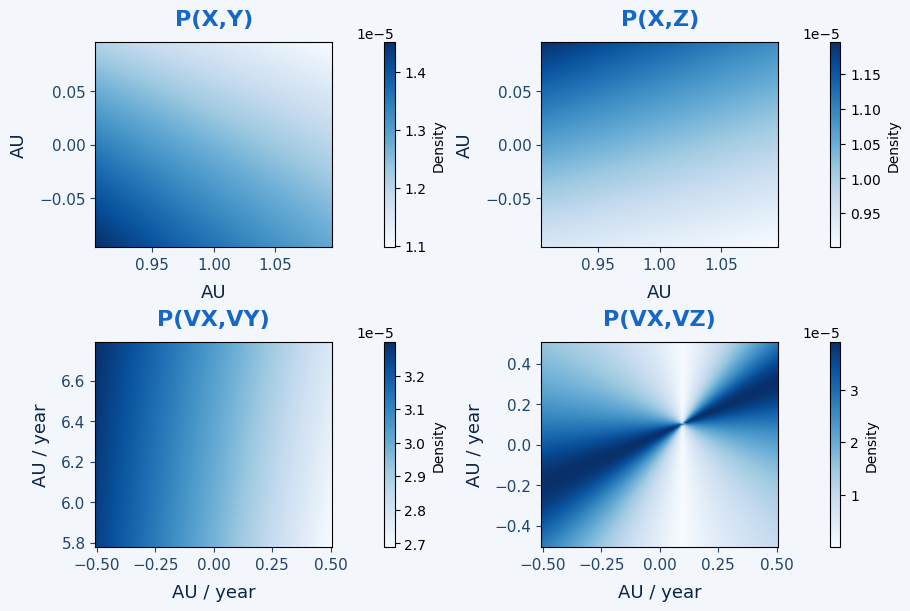

In [28]:
plot_configs = [
    {
        "data": P_XY,
        "extent": [xmin, xmax, ymin, ymax],
        "title": "P(X,Y)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_XZ,
        "extent": [xmin, xmax, zmin, zmax],
        "title": "P(X,Z)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_VXY,
        "extent": [vxmin, vxmax, vymin, vymax],
        "title": "P(VX,VY)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    },
    {
        "data": P_VXZ,
        "extent": [vxmin, vxmax, vzmin, vzmax],
        "title": "P(VX,VZ)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    }
]

# Use 'Blues' colormap and customize plot styling
fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True, facecolor="#f3f6fa")

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        plot_configs[i]["data"],
        origin='lower',
        cmap='Blues',
        interpolation='bilinear',
        extent=plot_configs[i]["extent"],
        aspect='auto'
    )
    ax.set_title(
        plot_configs[i]["title"], 
        fontsize=16, 
        color="#1767c6", 
        pad=12, 
        weight='bold'
    )
    ax.set_xlabel(plot_configs[i]["xlabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.set_ylabel(plot_configs[i]["ylabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#20456c')
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    fig.colorbar(
        im, 
        ax=ax, 
        fraction=0.045, 
        pad=0.04, 
        orientation='vertical', 
        label='Density'
    )
"""
plt.suptitle(
    'Probability Density Function $P(X)$ evaluated at the limits of the distribution state space vectors',
    fontsize=18,
    color='#15335b',
    fontweight='semibold',
    y=1.04
)
"""
plt.show()

In [5]:
def surface_integral_P_X(center, widths, n_points=8, mu=1):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()
    # Evaluate P at all points
    Pf = P_X_vectorized(Xf, Yf, Zf, VXf, VYf, VZf, mu)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    #return integral, y_points
    return integral

In [6]:
# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_X(center, widths, n_points=8, mu=mu)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

# Numerical: count number of objects in the volume from the sample
objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (N_theoretical * N)/N_numeric)

Theoretical (integral) number of objects in volume: 1649.9325646031014
Numerical (count) number of objects inside volume: 1787
Ratio 0.9232974620050931
